In [ ]:
import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import jax.numpy as jnp
import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import datetime
import os
import pickle

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

In [2]:
def load_camera_data(filepath):
    """Loads camera data (No Demographics)."""
    with open(filepath, 'r') as f:
        raw_data = json.load(f)
        
    lgtdata = raw_data["lgtdata"] if isinstance(raw_data, dict) and "lgtdata" in raw_data else raw_data

    X_list, y_list, unit_indices = [], [], []
    for i, respondent in enumerate(lgtdata):
        X_raw = np.atleast_2d(np.array(respondent['X']))
        y_raw = np.atleast_1d(np.array(respondent['y']))
        
        n_choice_occasions = len(y_raw)
        n_params = X_raw.shape[1]
        n_alts = X_raw.shape[0] // n_choice_occasions
        
        X_reshaped = X_raw.reshape((n_choice_occasions, n_alts, n_params))
        y_adjusted = y_raw - 1
        
        X_list.append(X_reshaped)
        y_list.append(y_adjusted)
        unit_indices.extend([i] * n_choice_occasions)

    return {
        "X": jnp.array(np.concatenate(X_list, axis=0)),
        "y": jnp.array(np.concatenate(y_list, axis=0)),
        "unit_idx": jnp.array(unit_indices),
        "n_units": len(lgtdata),
        "n_params": X_list[0].shape[2],
        "Z": None # Explicitly None for Camera
    }

def load_margarine_data(filepath):
    """Loads and preprocesses the margarine dataset (With Demographics)."""
    with open(filepath, 'r') as f:
        raw_data = json.load(f)
        
    lgtdata = raw_data["lgtdata"] if isinstance(raw_data, dict) and "lgtdata" in raw_data else raw_data
    
    X_list, y_list, Z_list, unit_indices = [], [], [], []
    
    n_alts_orig = 10
    kept_alts_1based = np.array([1, 2, 3, 4, 5, 7])
    kept_alts_0based = kept_alts_1based - 1 
    p = len(kept_alts_0based) 
    y_mapping = {val: idx for idx, val in enumerate(kept_alts_1based)}
    unit_idx_counter = 0
    
    for respondent in lgtdata:
        X_raw = np.array(respondent['X'])
        y_raw = np.atleast_1d(np.array(respondent['y']))
        
        n_choice_occasions_orig = len(y_raw)
        n_params_orig = X_raw.shape[1]
        X_reshaped = X_raw.reshape((n_choice_occasions_orig, n_alts_orig, n_params_orig))
        
        valid_occasions = np.isin(y_raw, kept_alts_1based)
        y_filtered = y_raw[valid_occasions]
        X_filtered = X_reshaped[valid_occasions]
        
        n_obs = len(y_filtered)
        if n_obs < 5: continue
            
        Z_raw = np.array(respondent.get('Z', [1.0, 1.0]))
        Z_list.append(Z_raw)
        y_recoded = np.array([y_mapping[val] for val in y_filtered])
        X_new = np.zeros((n_obs, p, p))
        
        for r in range(n_obs):
            orig_prices = X_filtered[r, kept_alts_0based, 9]
            X_new[r, 1:, 0:5] = np.eye(5)
            X_new[r, :, 5] = np.log(orig_prices)
            
        X_list.append(X_new)
        y_list.append(y_recoded)
        unit_indices.extend([unit_idx_counter] * n_obs)
        unit_idx_counter += 1

    Z_arr = np.array(Z_list)
    Z_arr[:, 0] = np.log(Z_arr[:, 0]) 
    Z_arr[:, 0] -= np.mean(Z_arr[:, 0]) 
    Z_arr[:, 1] -= np.mean(Z_arr[:, 1]) 
    Z_final = np.concatenate([np.ones((Z_arr.shape[0], 1)), Z_arr], axis=1)

    return {
        "X": jnp.array(np.concatenate(X_list, axis=0)),
        "y": jnp.array(np.concatenate(y_list, axis=0)),
        "Z": jnp.array(Z_final),
        "unit_idx": jnp.array(unit_indices),
        "n_units": unit_idx_counter,
        "n_params": p
    }

In [3]:
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(df=df, scale_tril=scale_tril, input_output_cholesky=True, validate_args=False)

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc, precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor), validate_args=False
    )

def build_unified_hmnl_model(data_dict, A_val=0.01):
    """Constructs the HBMNL model dynamically based on the presence of Z."""
    k_dim = int(data_dict["n_params"]) 
    n_units = int(data_dict["n_units"])
    has_Z = data_dict.get("Z") is not None

    nu_val = float(k_dim + 3)
    V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
    Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)

    # 1. Unobserved Heterogeneity Covariance
    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.eye(k_dim),
        distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
        name="sigma_inv_chol"
    )
    sigma_inv_chol_latent = sigma_inv_chol.transform(tfb.FillScaleTriL(), name="sigma_inv_chol_latent")
    mu_prec_factor = lsl.Var.new_calc(lambda L: jnp.sqrt(A_val) * L, L=sigma_inv_chol, name="mu_prec_factor")

    # 2. Baseline Utilities Branching Logic
    if has_Z:
        n_demos = data_dict["Z"].shape[1]
        Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        global_param = lsl.Var.new_param(
            value=jnp.zeros((n_demos, k_dim)),
            distribution=lsl.Dist(make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=mu_prec_factor),
            name="Delta"
        )
        loc_var = lsl.Var.new_calc(lambda z, delta: jnp.dot(z, delta), z=Z_var, delta=global_param, name="beta_loc")
    else:
        global_param = lsl.Var.new_param(
            value=jnp.zeros(k_dim),
            distribution=lsl.Dist(make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=mu_prec_factor),
            name="mu"
        )
        loc_var = global_param

    # 3. Unit-level coefficients & Likelihood
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, k_dim)),
        distribution=lsl.Dist(make_mvn_precision, loc=loc_var, precision_factor=sigma_inv_chol),
        name="beta_i"
    )

    X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
    beta_expanded = lsl.Var.new_calc(lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded")
    logits = lsl.Var.new_calc(lambda x, b: jnp.einsum("nij,nj->ni", x, b), x=X_var, b=beta_expanded, name="logits")
    y_var = lsl.Var.new_obs(data_dict["y"], distribution=lsl.Dist(tfd.Categorical, logits=logits), name="y")

    return lsl.Model([y_var])

def run_unified_inference(model, data_dict, chains=1, warmup=1000, posterior=10000, seed=123):
    """Sets up MCMC engine dynamically with optimized kernel ordering."""
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    global_param_name = "Delta" if data_dict.get("Z") is not None else "mu"
    
    # CRITICAL FIX: The covariance latent parameter MUST be updated first
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
    # Then the global means / demographics
    eb.add_kernel(gs.NUTSKernel([global_param_name])) 
    # Finally the unit-level betas
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print(f"Starting NUTS Sampling (Targeting: {global_param_name})...")
    engine = eb.build()
    engine.sample_all_epochs()

    return engine.get_results(), engine.get_results().get_posterior_samples()

In [5]:
camera_path = "../camera/camera_data.json" 
print("Loading Camera Data...")
data_cam = load_camera_data(camera_path)
model_cam = build_unified_hmnl_model(data_cam)

start_time = time.time()
res_cam, samps_cam = run_unified_inference(model_cam, data_cam, chains=1, warmup=1000, posterior=10000)
print(f"Camera Sampling finished in {str(datetime.timedelta(seconds=int(time.time() - start_time)))}")

# Save Results
os.makedirs("Data", exist_ok=True)
with open("Data/unified_samples_camera.pkl", "wb") as f:
    pickle.dump({"samples": samps_cam}, f)
print("Saved unified_samples_camera.pkl")

Loading Camera Data...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling (Targeting: mu)...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:17<00:00,  5.90s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 12 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 413.39chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2 / 25 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - I

Camera Sampling finished in 0:17:35
Saved unified_samples_camera.pkl


In [6]:
margarine_path = "../margarine/margarine_data.json" 
print("Loading Margarine Data...")
data_marg = load_margarine_data(margarine_path)
model_marg = build_unified_hmnl_model(data_marg)

start_time = time.time()
res_marg, samps_marg = run_unified_inference(model_marg, data_marg, chains=1, warmup=1000, posterior=10000)
print(f"Margarine Sampling finished in {str(datetime.timedelta(seconds=int(time.time() - start_time)))}")

# Save Results
with open("Data/unified_samples_margarine.pkl", "wb") as f:
    pickle.dump({"samples": samps_marg}, f)
print("Saved unified_samples_margarine.pkl")

Loading Margarine Data...


liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling (Targeting: Delta)...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:17<00:00,  5.75s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 6 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 58 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 447.34chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 22 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1 / 25 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - 

Margarine Sampling finished in 0:04:25
Saved unified_samples_margarine.pkl



--- Testing Camera Equivalence ---


,Old Mean,Unified Mean,Diff (Mean)
Parameter,,,
Canon,2.0077,2.0153,0.0076
Sony,1.5774,1.5802,0.0028
Nikon,1.7033,1.7114,0.0082
Panasonic,1.1760,1.1838,0.0078
Pixels,1.4323,1.4295,0.0028
Zoom,1.7572,1.7553,0.0020
Video,1.3334,1.3334,0.0000
Swivel,0.7675,0.7663,0.0012
Wifi,1.2103,1.2089,0.0014


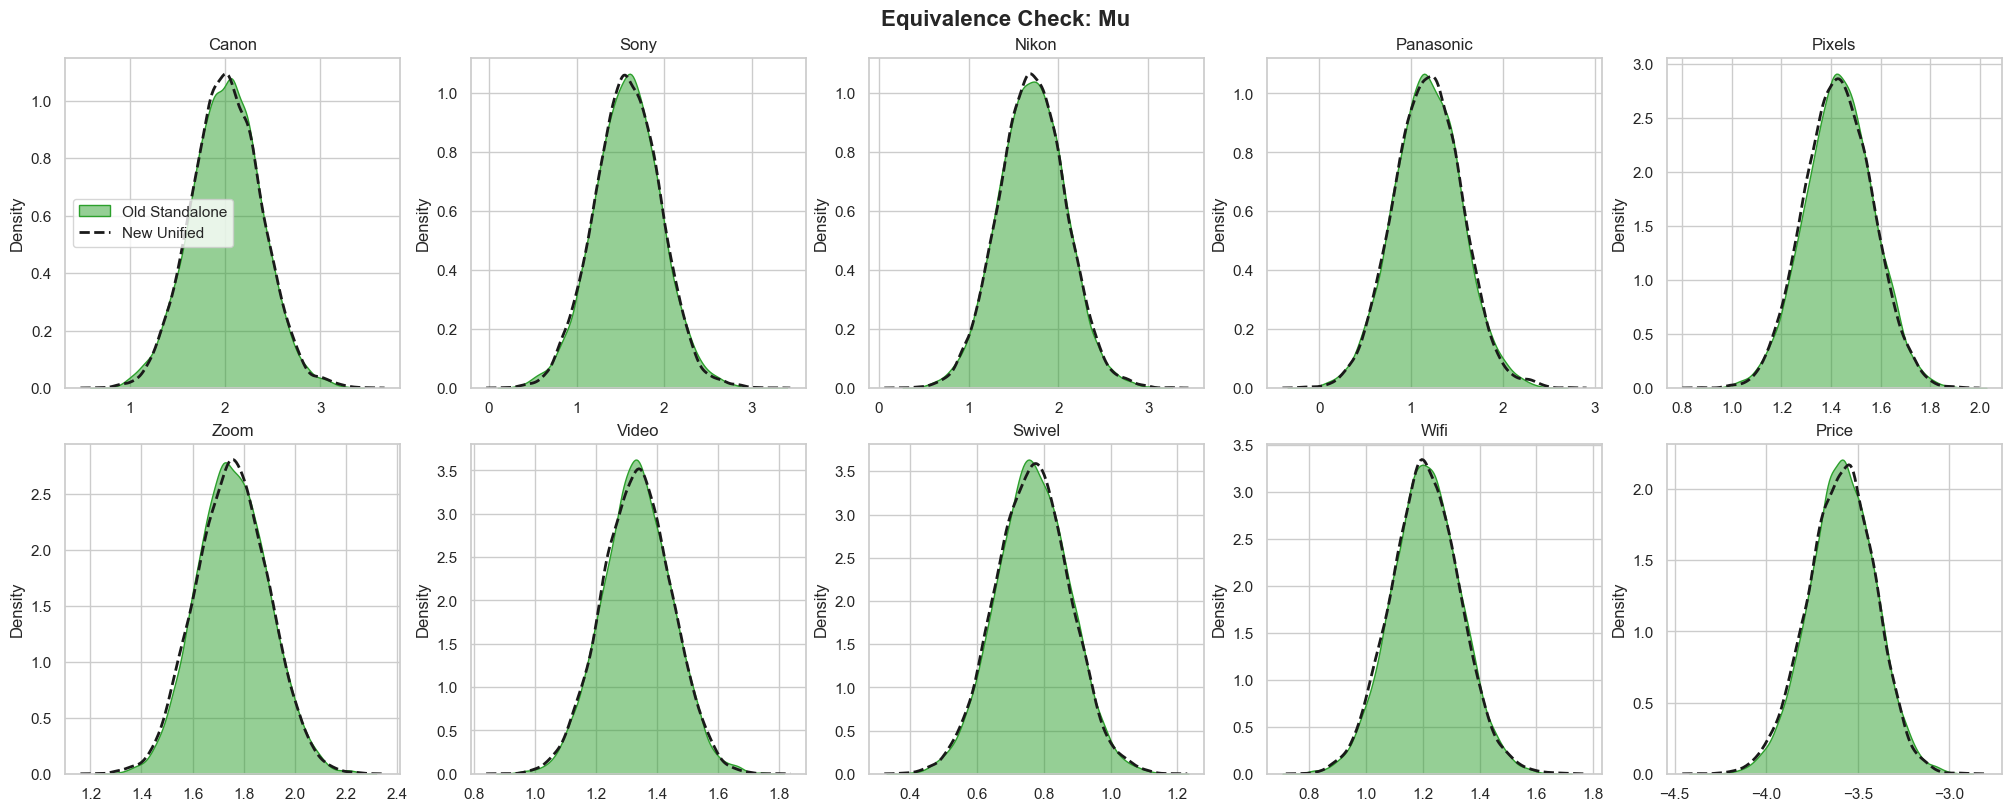


--- Testing Margarine Equivalence ---


,Old Mean,Unified Mean,Diff (Mean)
Parameter,,,
Blue Bonnet,-1.1390,-1.1497,0.0108
Fleischmanns,-3.6205,-3.7395,0.1190
House,-2.4652,-2.4707,0.0056
Generic,-4.9892,-4.9378,0.0513
Shed Spread,-1.7505,-1.7932,0.0427
log(price),-4.0330,-4.0048,0.0282


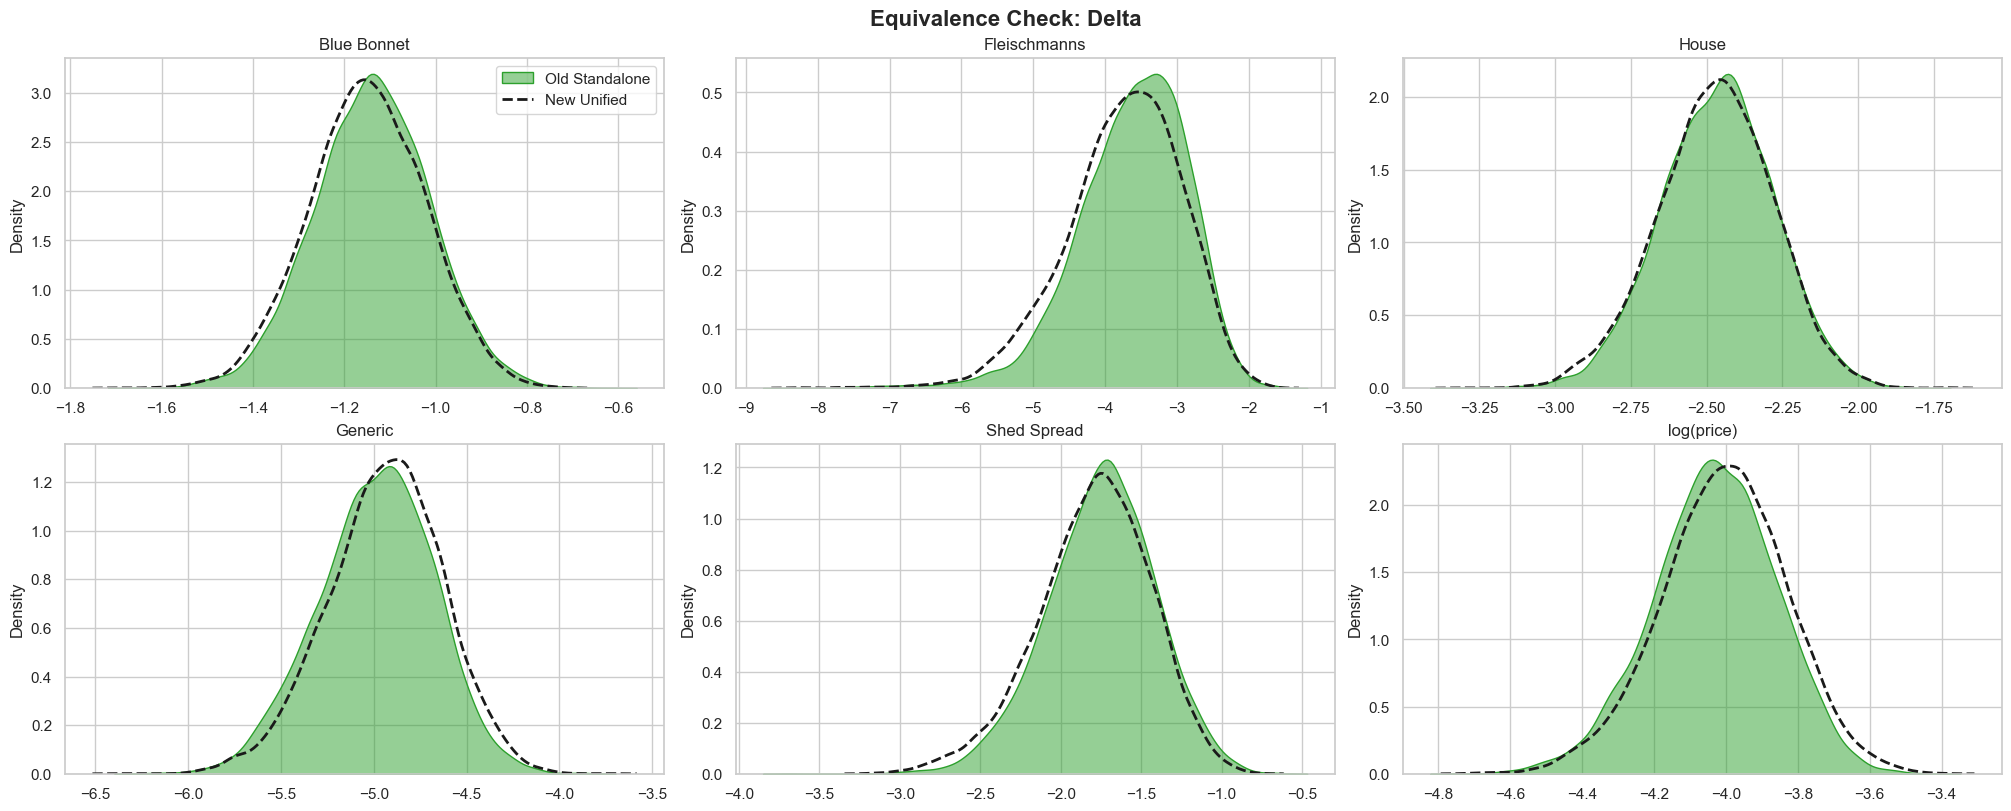

In [7]:
def plot_equivalence(old_samps_path, new_samps, param_target, param_names):
    """Compares the old standalone script outputs to the new unified outputs."""
    with open(old_samps_path, "rb") as f:
        old_data = pickle.load(f)
        
    # Handle dictionary nesting depending on how it was saved
    old_samps = old_data["samples"] if "samples" in old_data else old_data
    
    k_dim = len(param_names)
    
    # Extract based on whether we are looking at 'mu' or 'Delta'
    if param_target == "mu":
        old_vals = old_samps["mu"].reshape(-1, k_dim)
        new_vals = new_samps["mu"].reshape(-1, k_dim)
    else:
        n_demos = new_samps["Delta"].shape[2] if new_samps["Delta"].ndim == 4 else new_samps["Delta"].shape[1]
        old_vals = old_samps["Delta"].reshape(-1, n_demos, k_dim)[:, 0, :] # Extracting Intercepts for comparison
        new_vals = new_samps["Delta"].reshape(-1, n_demos, k_dim)[:, 0, :]
        
    comp_df = pd.DataFrame({
        "Parameter": param_names,
        "Old Mean": np.mean(old_vals, axis=0),
        "Unified Mean": np.mean(new_vals, axis=0),
        "Diff (Mean)": np.abs(np.mean(old_vals, axis=0) - np.mean(new_vals, axis=0)),
    }).set_index("Parameter")
    
    display(comp_df.round(4))
    
    # Plot overlaps
    fig, axes = plt.subplots(2, (k_dim + 1) // 2, figsize=(20, 8), constrained_layout=True)
    for i, (ax, param) in enumerate(zip(axes.flatten(), param_names)):
        sns.kdeplot(old_vals[:, i], ax=ax, fill=True, color="#2ca02c", alpha=0.5, label="Old Standalone")
        sns.kdeplot(new_vals[:, i], ax=ax, fill=False, color="k", linestyle="--", linewidth=2, label="New Unified")
        ax.set_title(param)
        if i == 0: ax.legend()
    plt.suptitle(f"Equivalence Check: {param_target.capitalize()}", fontsize=16, fontweight='bold')
    plt.show()

print("\n--- Testing Camera Equivalence ---")
cam_params = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]
plot_equivalence("../camera/Data/liesel_posterior_samples_camera.pkl", samps_cam, "mu", cam_params)

print("\n--- Testing Margarine Equivalence ---")
marg_params = ["Blue Bonnet", "Fleischmanns", "House", "Generic", "Shed Spread", "log(price)"]
plot_equivalence("../margarine/Data/liesel_posterior_samples_demeaned.pkl", samps_marg, "Delta", marg_params)